## Eigenvalues

In [1]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt

import scipy.io as sio

In [2]:
def _maybe_transpose(a):
    # For MATLAB v7.3 via h5py, 2D arrays often come out transposed
    if a.ndim == 2:
        return a.T
    return a

def _to_complex_if_compound(arr):
    # MATLAB v7.3 complex arrays can appear as compound dtype with fields ('real','imag')
    if hasattr(arr.dtype, "fields") and arr.dtype.fields is not None:
        fields = arr.dtype.fields
        if "real" in fields and "imag" in fields:
            return arr["real"] + 1j * arr["imag"]
    return arr

def load_mat_var(path, varname="D"):
    """
    Returns numpy array for variable `varname` from a MATLAB .mat file.
    Supports both -v7.2 (scipy.io.loadmat) and -v7.3 (h5py).
    """
    try:
        md = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        if varname not in md:
            keys = [k for k in md.keys() if not k.startswith("__")]
            raise KeyError(f"'{varname}' not found. Keys: {keys}")
        arr = np.asarray(md[varname])
        return arr
    except NotImplementedError:
        # Likely MATLAB -v7.3
        import h5py
        with h5py.File(path, "r") as f:
            if varname not in f:
                keys = list(f.keys())
                raise KeyError(f"'{varname}' not found in HDF5. Keys: {keys}")
            ds = f[varname]
            arr = np.array(ds)
            arr = _maybe_transpose(arr)
            arr = _to_complex_if_compound(arr)
            return arr

In [3]:
RESULT_DIR = "linear_wave_ssm_results/test_bc"
pattern = os.path.join(
    RESULT_DIR,
    "CNstepping_Neumann_skewsymbeta_bounduvtq30_2hr_0.5_damp_1day_diffxuv_4e4_hydiff_0.8_wn_*_latbnd_60_dlat_1_rigidlid.mat"
)

files = sorted(glob.glob(pattern))
print("Found", len(files), "files")

def parse_wn(fname):
    m = re.search(r"_wn_(\d+)_", os.path.basename(fname))
    if not m:
        raise ValueError(f"Cannot parse wn from: {fname}")
    return int(m.group(1))

# Load
data_by_wn = {}
for f in files:
    wn = parse_wn(f)
    D = load_mat_var(f, "D")   # shape (N,3)
    D = np.atleast_2d(D)
    mu = D[:, 0].astype(np.complex128, copy=False)
    growth = np.real(D[:, 1])  # per day (already computed in MATLAB)
    freq = np.real(D[:, 2])    # cycles/day
    data_by_wn[wn] = {"mu": mu, "growth": growth, "freq": freq}

wns = sorted(data_by_wn.keys())
print("Loaded wavenumbers:", wns[:5], "...", wns[-5:])

Found 41 files
Loaded wavenumbers: [0, 1, 2, 3, 4] ... [36, 37, 38, 39, 40]


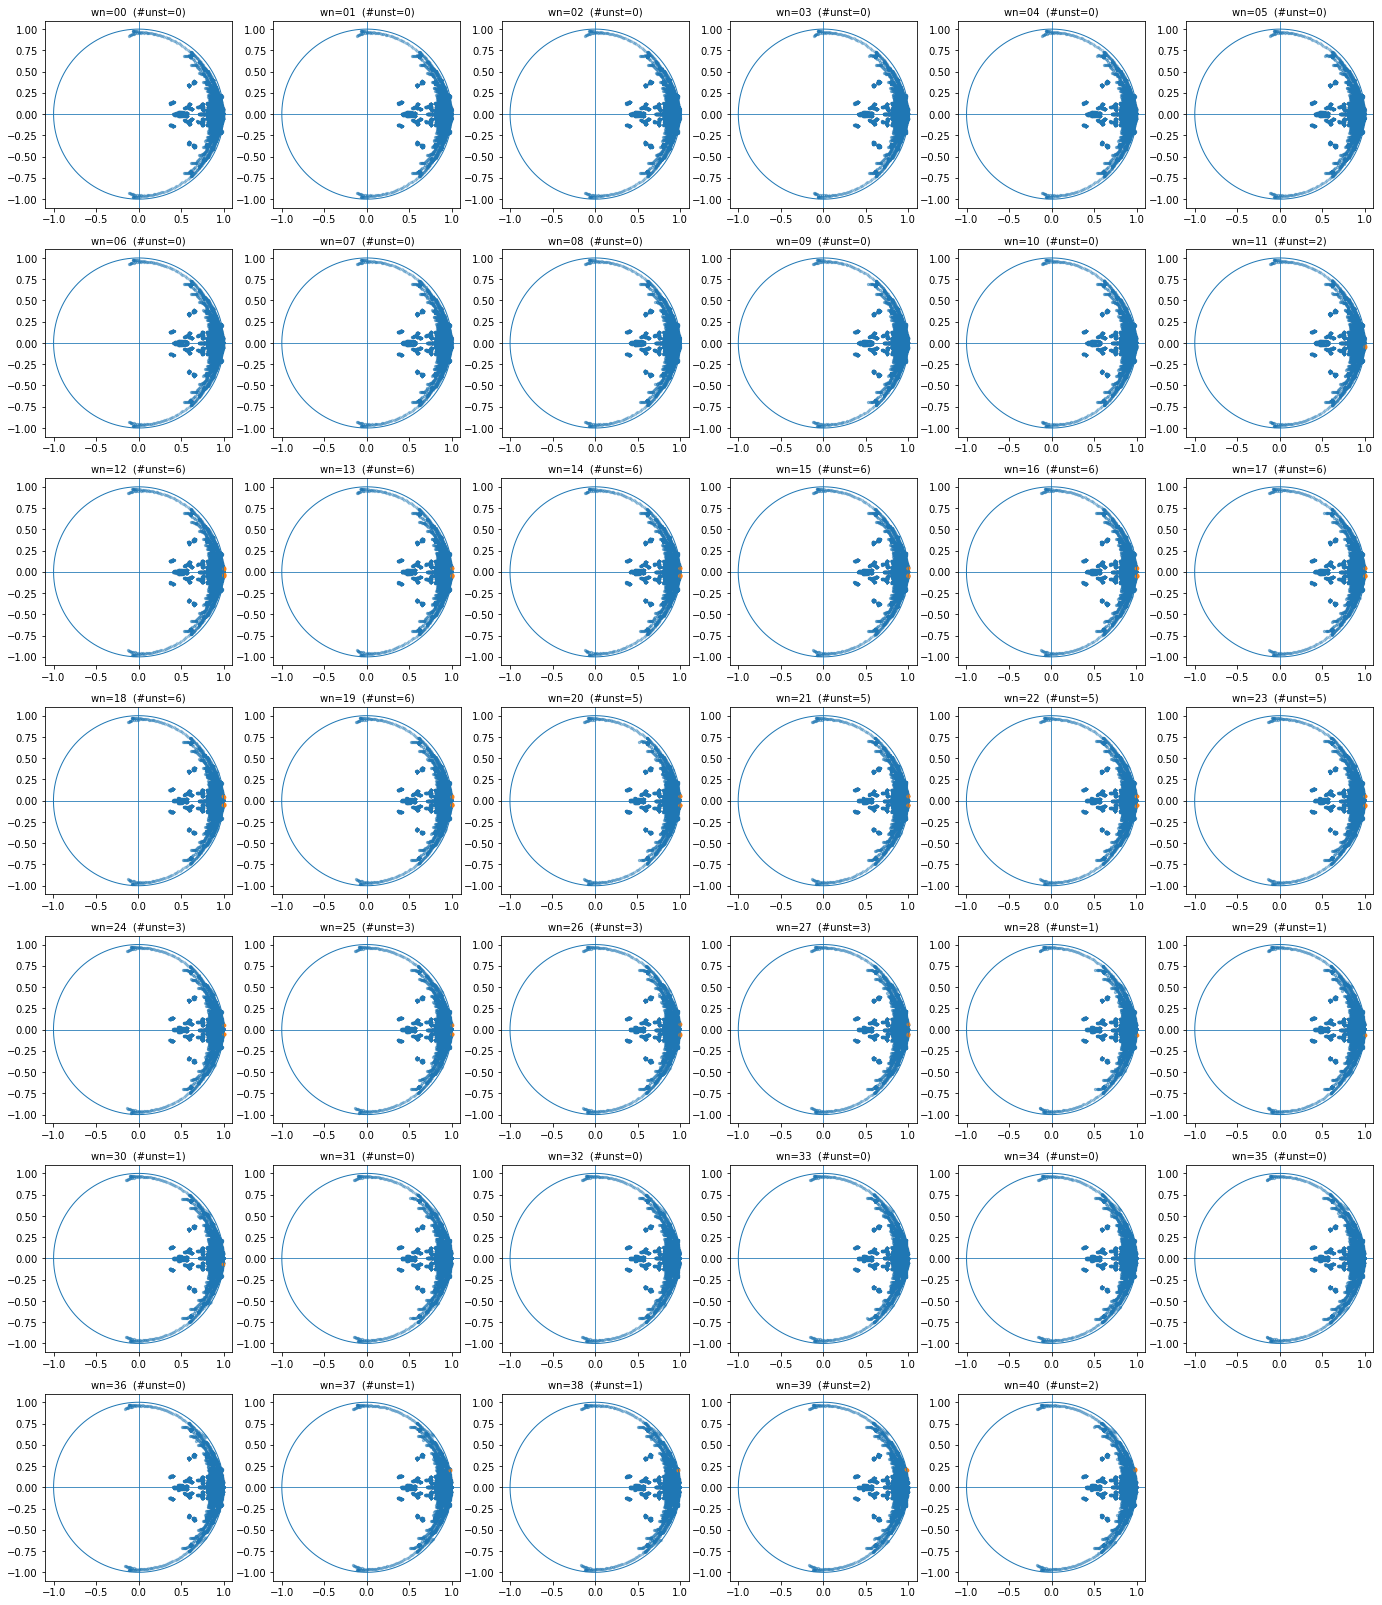

In [4]:
n = len(wns)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows))
axes = np.atleast_1d(axes).ravel()

theta = np.linspace(0, 2*np.pi, 400)
uc_x, uc_y = np.cos(theta), np.sin(theta)

for ax, wn in zip(axes, wns):
    mu = data_by_wn[wn]["mu"]
    growth = data_by_wn[wn]["growth"]

    # stable vs unstable highlight using growth > 0 (equivalently |mu|>1 if consistent)
    stable = growth <= 0
    unstable = growth > 0

    ax.scatter(mu.real[stable],   mu.imag[stable],   s=5, alpha=0.25)
    ax.scatter(mu.real[unstable], mu.imag[unstable], s=8, alpha=0.9)

    ax.plot(uc_x, uc_y, linewidth=1)  # unit circle
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"wn={wn:02d}  (#unst={unstable.sum()})", fontsize=10)

for ax in axes[len(wns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Plotted points: 91 (growth_min=0.0)


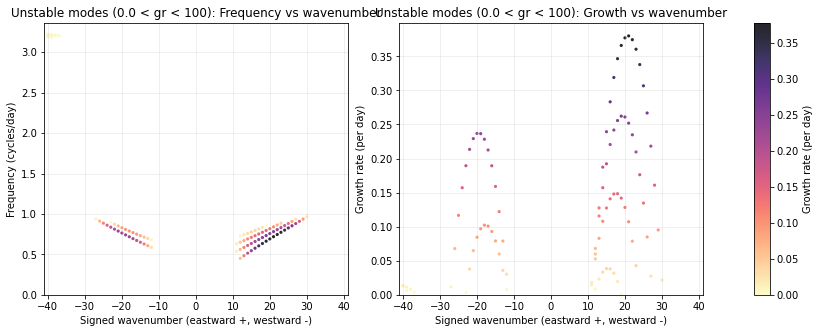

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

growth_min = 0.
growth_max = 100
cmap_name = "magma_r"
marker_size = 10
alpha = 0.85
vmax_percentile = 99

xs, freq_pos, growths = [], [], []

for wn in sorted(data_by_wn.keys()):
    g = np.asarray(data_by_wn[wn]["growth"])
    f = np.asarray(data_by_wn[wn]["freq"])

    unstable = (g > growth_min) & (g <= growth_max)
    if not np.any(unstable):
        continue

    g_u = g[unstable]
    f_u = f[unstable]
    x_u = np.where(f_u < 0, +wn, -wn)

    xs.append(x_u)
    freq_pos.append(np.abs(f_u))
    growths.append(g_u)

xs = np.concatenate(xs) if xs else np.array([])
freq_pos = np.concatenate(freq_pos) if freq_pos else np.array([])
growths = np.concatenate(growths) if growths else np.array([])

print(f"Plotted points: {growths.size} (growth_min={growth_min})")

if growths.size > 0:
    wn_max = max(data_by_wn.keys())

    vmin = growth_min
    vmax = np.percentile(growths, vmax_percentile)
    if vmax <= vmin:
        vmax = growths.max()

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(13, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharex=ax0)
    cax = fig.add_subplot(gs[0, 2])

    sc0 = ax0.scatter(xs, freq_pos, c=growths, cmap=cmap, norm=norm,
                     s=marker_size, alpha=alpha, linewidths=0)
    ax0.set_xlabel("Signed wavenumber (eastward +, westward -)")
    ax0.set_ylabel("Frequency (cycles/day)")
    ax0.set_title(f"Unstable modes ({growth_min} < gr < {growth_max}): Frequency vs wavenumber")
    ax0.set_xlim(-wn_max - 1, wn_max + 1)
    ax0.set_ylim(bottom=0)              # <-- left panel starts at 0
    ax0.grid(True, alpha=0.25)

    sc1 = ax1.scatter(xs, growths, c=growths, cmap=cmap, norm=norm,
                     s=marker_size, alpha=alpha, linewidths=0)
    ax1.set_xlabel("Signed wavenumber (eastward +, westward -)")
    ax1.set_ylabel("Growth rate (per day)")
    ax1.set_title(f"Unstable modes ({growth_min} < gr < {growth_max}): Growth vs wavenumber")
    ax1.set_xlim(-wn_max - 1, wn_max + 1)
    ax1.set_ylim(bottom=growth_min)     # <-- right panel starts at threshold
    ax1.grid(True, alpha=0.25)

    cb = fig.colorbar(sc0, cax=cax)
    cb.set_label("Growth rate (per day)")

    plt.show()

## Eigenmodes

In [6]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.io as sio


In [7]:
# -----------------------
# User settings
# -----------------------
RESULT_DIR = "linear_wave_ssm_results/test_bc"
wn   = 20
dlat = 1                    # matches filename dlat_{dlat}
growth_min = 0.0            # e.g. 0.6
mode_rank  = 0              # 0 = most unstable among growth>growth_min

SYS_C_TXT  = "sys_C.txt"    # uploaded/exported sys.C
DM_MAT     = "IDEAL_dm.mat" # must be available in your working dir
# -----------------------


In [8]:
# -----------------------
# Robust .mat loader (v7.2 + v7.3)
# -----------------------
def _maybe_transpose(a):
    return a.T if a.ndim == 2 else a

def _to_complex_if_compound(arr):
    # v7.3 complex arrays may appear as compound dtype with fields ('real','imag')
    if hasattr(arr.dtype, "fields") and arr.dtype.fields is not None:
        fields = arr.dtype.fields
        if "real" in fields and "imag" in fields:
            return arr["real"] + 1j * arr["imag"]
    return arr

def load_mat_vars(path, varnames=("D","V","lat_deg","z")):
    """
    Returns dict of requested variables. Supports MATLAB v7.2 (loadmat) and v7.3 (h5py).
    """
    out = {}
    try:
        md = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        for vn in varnames:
            if vn not in md:
                keys = [k for k in md.keys() if not k.startswith("__")]
                raise KeyError(f"'{vn}' not found. Keys: {keys}")
            out[vn] = np.asarray(md[vn])
        return out
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            for vn in varnames:
                if vn not in f:
                    raise KeyError(f"'{vn}' not found in HDF5. Keys: {list(f.keys())}")
                arr = np.array(f[vn])
                arr = _maybe_transpose(arr)
                arr = _to_complex_if_compound(arr)
                out[vn] = arr
        return out

# -----------------------
# Geometry / reshape helpers
# -----------------------
def edges_1d(x):
    x = np.asarray(x).ravel()
    xm = 0.5*(x[1:] + x[:-1])
    x0 = x[0] - (xm[0] - x[0])
    xN = x[-1] + (x[-1] - xm[-1])
    return np.concatenate([[x0], xm, [xN]])

def plot_lat_z(ax, lat, z, field_lat_z, title="", ylabel=True):
    """
    field_lat_z shape: (nlat, nz)
    """
    lat = np.asarray(lat).ravel()
    z = np.asarray(z).ravel()
    F = np.asarray(field_lat_z)

    lat_e = edges_1d(lat)
    z_e   = edges_1d(z)

    pcm = ax.pcolormesh(lat_e, z_e/1000.0, F.T, shading="auto")
    ax.set_title(title)
    ax.set_xlabel("Latitude (deg)")
    if ylabel:
        ax.set_ylabel("z (km)")
    ax.grid(True, alpha=0.2)
    return pcm

def infer_slat_from_lat(lat_deg):
    dlat_here = float(np.median(np.diff(lat_deg)))
    slat = lat_deg[1:] - dlat_here/2
    # slat = np.concatenate([lat_deg - dlat_here/2, [lat_deg[-1] + dlat_here/2]])
    return slat, dlat_here

def reshape_mode(vec, ny):
    """
    Layout assumed:
      x   : ny*120
      du  : ny*26
      dv  : (ny-1)*26
    """
    vec = np.asarray(vec).ravel()
    n_x  = ny * 120
    n_du = ny * 26
    n_dv = (ny - 1) * 26
    Nexp = n_x + n_du + n_dv
    if vec.size != Nexp:
        raise ValueError(f"Size mismatch: vec has {vec.size}, expected {Nexp}")

    x  = vec[:n_x].reshape(ny, 120)
    du = vec[n_x:n_x+n_du].reshape(ny, 26)
    dv = vec[n_x+n_du:].reshape(ny-1, 26)
    return x, du, dv

def phase_align(vec):
    """Rotate global phase so the largest-magnitude entry becomes real-positive."""
    vec = np.asarray(vec).ravel()
    k = np.argmax(np.abs(vec))
    phi = np.angle(vec[k])
    return vec * np.exp(-1j*phi)

def symmetric_norm(arrs, pct=99):
    vals = np.concatenate([np.ravel(a) for a in arrs])
    vmax = np.percentile(np.abs(vals), pct)
    if vmax == 0:
        vmax = np.max(np.abs(vals))
    return mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


In [9]:
# -----------------------
# Load C_raw from sys_C.txt and apply MATLAB-style mass_weight scaling
# MATLAB did:
#   mass_weight = diag(sqrt([dm(1:26); 2.5^2*dm(1:14)]))
#   C = mass_weight \ sys.C
#   C(27:40,:) *= 1e-3  (gram/kg)
# -----------------------
def load_C_from_txt(c_path):
    C = np.loadtxt(c_path)
    if C.shape == (120, 40):
        C = C.T
    if C.shape != (40, 120):
        raise ValueError(f"sys_C.txt loaded shape {C.shape}, expected (40,120) or (120,40)")
    return C

def build_C_scaled(C_raw, dm_mat_path, gram_per_kg=1e-3):
    mdm = sio.loadmat(dm_mat_path, squeeze_me=True, struct_as_record=False)
    if "dm" not in mdm:
        keys = [k for k in mdm.keys() if not k.startswith("__")]
        raise KeyError(f"'dm' not found in {dm_mat_path}. Keys: {keys}")
    dm = np.asarray(mdm["dm"], dtype=float).ravel()

    mass_diag = np.sqrt(np.concatenate([dm[:26], (2.5**2)*dm[:14]]))  # (40,)
    C_scaled = C_raw / mass_diag[:, None]  # diagonal solve (mass_weight \ C_raw)

    C_scaled[26:40, :] *= gram_per_kg      # Q rows scaling
    return C_scaled

C_raw = load_C_from_txt(SYS_C_TXT)
C = build_C_scaled(C_raw, DM_MAT, gram_per_kg=1e-3)
print("C_scaled shape:", C.shape)


C_scaled shape: (40, 120)


In [10]:
# -----------------------
# Load eigen result file
# -----------------------
pat = os.path.join(
    RESULT_DIR,
    f"CNstepping_Neumann_skewsymbeta_bounduvtq30_2hr_0.5_damp_1day_diffxuv_4e4_hydiff_0.8_wn_{wn:02d}_latbnd_60_dlat_{dlat}_rigidlid.mat"
)
cands = sorted(glob.glob(pat))
if not cands:
    raise FileNotFoundError(f"No file matched: {pat}")
path = cands[0]
print("Using:", path)

S = load_mat_vars(path, ("D","V","lat_deg","z"))
D = np.atleast_2d(S["D"])
V = S["V"]
lat_deg = np.asarray(S["lat_deg"]).ravel()
z = np.asarray(S["z"]).ravel()   # you said: bottom -> top

mu     = D[:,0].astype(np.complex128, copy=False)
growth = np.real(D[:,1])   # per day
freq   = np.real(D[:,2])   # cpd

ny = lat_deg.size
slat_deg, dlat_here = infer_slat_from_lat(lat_deg)

# Select unstable modes by growth threshold and pick by rank
idx = np.where((growth > growth_min) & (abs(freq) <= 2))[0]
if idx.size == 0:
    raise RuntimeError(f"No modes with growth > {growth_min}")
idx_sorted = idx[np.argsort(growth[idx])[::-1]]
for mode_rank in range(idx_sorted.size):
    j = idx_sorted[mode_rank]
    print(f"Selected mode index {j}, growth={growth[j]:.3f}/day, freq={freq[j]:.3f} cpd, |mu|={abs(mu[j]):.6f}")
    


Using: linear_wave_ssm_results/test_bc/CNstepping_Neumann_skewsymbeta_bounduvtq30_2hr_0.5_damp_1day_diffxuv_4e4_hydiff_0.8_wn_20_latbnd_60_dlat_1_rigidlid.mat
Selected mode index 7568, growth=0.377/day, freq=-0.691 cpd, |mu|=1.003936
Selected mode index 7566, growth=0.261/day, freq=-0.757 cpd, |mu|=1.002722
Selected mode index 7407, growth=0.237/day, freq=0.765 cpd, |mu|=1.002470
Selected mode index 7567, growth=0.128/day, freq=-0.818 cpd, |mu|=1.001336
Selected mode index 7408, growth=0.084/day, freq=0.830 cpd, |mu|=1.000880


In [11]:
slat_deg, dlat_here = infer_slat_from_lat(lat_deg)

In [12]:
# -----------------------
# Extract mode, reshape, compute T/Q = C*x
# -----------------------
j = np.random.choice(idx_sorted)  # pick randomly among top unstable modes
vec = phase_align(V[:, j])
x, du, dv = reshape_mode(vec, ny)

# C*x: x is (ny,120), C is (40,120) -> Y is (ny,40)
Y = x @ C.T
T = Y[:, :26]        # (ny,26)
Q = Y[:, 26:40]      # (ny,14)

# z is bottom->top center levels; you only model bottom 26 layers
z26 = z[:26]
z14 = z26[:14]

print("Shapes:",
      "T", T.shape, "Q", Q.shape,
      "du", du.shape, "dv", dv.shape,
      "z26", z26.shape, "z14", z14.shape)


Shapes: T (120, 26) Q (120, 14) du (120, 26) dv (119, 26) z26 (26,) z14 (14,)


In [13]:
j = np.random.choice(idx_sorted)  # pick randomly among top unstable modes
vec = phase_align(V[:, j])
x, du, dv = reshape_mode(vec, ny)

import numpy as np

def block_norm(A):
    A = np.asarray(A)
    return np.linalg.norm(A.ravel())  # Frobenius norm for complex arrays

nx = block_norm(x)
nu = block_norm(du)
nv = block_norm(dv)

tot = nx + nu + nv
print(f"||x||  = {nx:.3e}  frac={nx/tot:.3f}")
print(f"||du|| = {nu:.3e}  frac={nu/tot:.3f}")
print(f"||dv|| = {nv:.3e}  frac={nv/tot:.3f}")

# C: shape (40,120)
Y = x @ C.T          # (ny,40), complex
T = Y[:, :26]        # (ny,26)
Q = Y[:, 26:40]      # (ny,14)

nCx = block_norm(Y)
nT  = block_norm(T)
nQ  = block_norm(Q)

print(f"||Cx|| = {nCx:.3e}")
print(f"||T||  = {nT:.3e}  (frac of Cx={nT/nCx:.3f})")
print(f"||Q||  = {nQ:.3e}  (frac of Cx={nQ/nCx:.3f})")
print(f"||Cx||/||x|| = {nCx/nx:.3e}")

def latband_norm(field_lat_k, lat_deg, band):
    """band = (lo, hi) in degrees of |lat|."""
    lo, hi = band
    lat = np.asarray(lat_deg).ravel()
    m = (np.abs(lat) >= lo) & (np.abs(lat) < hi)
    F = np.asarray(field_lat_k)
    # works for (ny,k); if field is on slat, pass slat_deg instead
    return np.linalg.norm(F[m, :].ravel())

bands = [(0,10),(10,20),(20,30),(30,40),(40,60)]
for b in bands:
    print(b, "||T||:", latband_norm(T, lat_deg, b))

||x||  = 9.999e-01  frac=0.979
||du|| = 1.436e-02  frac=0.014
||dv|| = 6.692e-03  frac=0.007
||Cx|| = 1.213e+01
||T||  = 1.213e+01  (frac of Cx=1.000)
||Q||  = 5.399e-03  (frac of Cx=0.000)
||Cx||/||x|| = 1.214e+01
(0, 10) ||T||: 9.86883789759277
(10, 20) ||T||: 7.022931474232557
(20, 30) ||T||: 0.7328933700763522
(30, 40) ||T||: 0.01070352814875684
(40, 60) ||T||: 7.896949419177298e-06


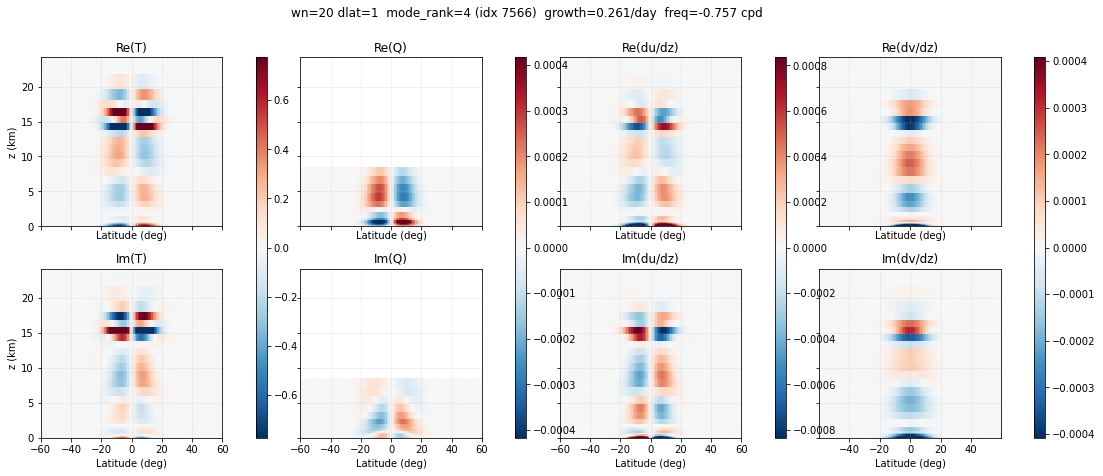

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def symmetric_norm(arrs, pct=99):
    vals = np.concatenate([np.ravel(a) for a in arrs])
    vmax = np.percentile(np.abs(vals), pct)
    if vmax == 0:
        vmax = np.max(np.abs(vals))
    return mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# norms per variable (shared for Re/Im)
normT  = symmetric_norm([np.real(T),  np.imag(T)],  pct=99)
normQ  = symmetric_norm([np.real(Q),  np.imag(Q)],  pct=99)
normdu = symmetric_norm([np.real(du), np.imag(du)], pct=99)
normdv = symmetric_norm([np.real(dv), np.imag(dv)], pct=99)

cmap = "RdBu_r"

# Wider colorbar columns + larger wspace => more gap to the right
fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(
    nrows=2, ncols=8,
    width_ratios=[1, 0.06, 1, 0.06, 1, 0.06, 1, 0.06],
    wspace=0.35, hspace=0.25
)

# data panels
axT_re  = fig.add_subplot(gs[0,0])
axT_im  = fig.add_subplot(gs[1,0], sharex=axT_re, sharey=axT_re)

axQ_re  = fig.add_subplot(gs[0,2], sharey=axT_re)
axQ_im  = fig.add_subplot(gs[1,2], sharex=axQ_re, sharey=axT_re)

axdu_re = fig.add_subplot(gs[0,4], sharey=axT_re)
axdu_im = fig.add_subplot(gs[1,4], sharex=axdu_re, sharey=axT_re)

axdv_re = fig.add_subplot(gs[0,6], sharey=axT_re)
axdv_im = fig.add_subplot(gs[1,6], sharex=axdv_re, sharey=axT_re)

# colorbar axes (outside)
caxT  = fig.add_subplot(gs[:,1])
caxQ  = fig.add_subplot(gs[:,3])
caxdu = fig.add_subplot(gs[:,5])
caxdv = fig.add_subplot(gs[:,7])

# ---- plot panels (only leftmost has y-label) ----
pcmT_re = plot_lat_z(axT_re, lat_deg, z26, np.real(T),  title="Re(T)", ylabel=True)
pcmT_im = plot_lat_z(axT_im, lat_deg, z26, np.imag(T),  title="Im(T)", ylabel=True)

pcmQ_re = plot_lat_z(axQ_re, lat_deg, z14, np.real(Q),  title="Re(Q)", ylabel=False)
pcmQ_im = plot_lat_z(axQ_im, lat_deg, z14, np.imag(Q),  title="Im(Q)", ylabel=False)

pcmu_re = plot_lat_z(axdu_re, lat_deg, z26, np.real(du), title="Re(du/dz)", ylabel=False)
pcmu_im = plot_lat_z(axdu_im, lat_deg, z26, np.imag(du), title="Im(du/dz)", ylabel=False)

pcmv_re = plot_lat_z(axdv_re, slat_deg, z26, np.real(dv), title="Re(dv/dz)", ylabel=False)
pcmv_im = plot_lat_z(axdv_im, slat_deg, z26, np.imag(dv), title="Im(dv/dz)", ylabel=False)

# apply colormap + norm
for pcm in (pcmT_re, pcmT_im):
    pcm.set_cmap(cmap); pcm.set_norm(normT)
for pcm in (pcmQ_re, pcmQ_im):
    pcm.set_cmap(cmap); pcm.set_norm(normQ)
for pcm in (pcmu_re, pcmu_im):
    pcm.set_cmap(cmap); pcm.set_norm(normdu)
for pcm in (pcmv_re, pcmv_im):
    pcm.set_cmap(cmap); pcm.set_norm(normdv)

# colorbars: no titles/labels
fig.colorbar(pcmT_re, cax=caxT)
fig.colorbar(pcmQ_re, cax=caxQ)
fig.colorbar(pcmu_re, cax=caxdu)
fig.colorbar(pcmv_re, cax=caxdv)

# hide x tick labels on top row
for ax in (axT_re, axQ_re, axdu_re, axdv_re):
    ax.tick_params(labelbottom=False)

for ax in (axQ_re, axQ_im, axdu_re, axdu_im, axdv_re, axdv_im):
    ax.tick_params(labelleft=False)

fig.suptitle(
    f"wn={wn:02d} dlat={dlat}  mode_rank={mode_rank} (idx {j})  growth={growth[j]:.3f}/day  freq={freq[j]:.3f} cpd",
    y=0.98
)

plt.show()


Mode index 7568, growth=0.377/day, freq=-0.691 cpd, |mu|=1.003936


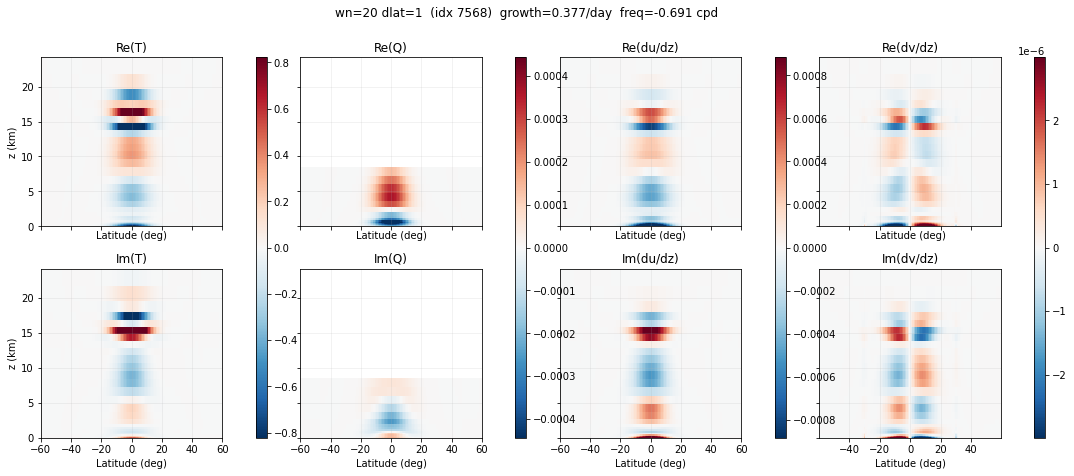

Mode index 7566, growth=0.261/day, freq=-0.757 cpd, |mu|=1.002722


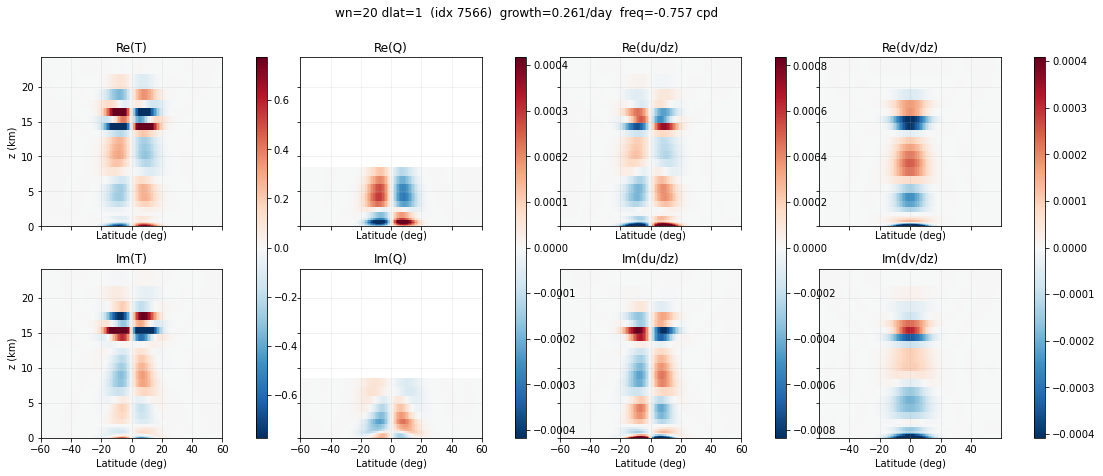

Mode index 7407, growth=0.237/day, freq=0.765 cpd, |mu|=1.002470


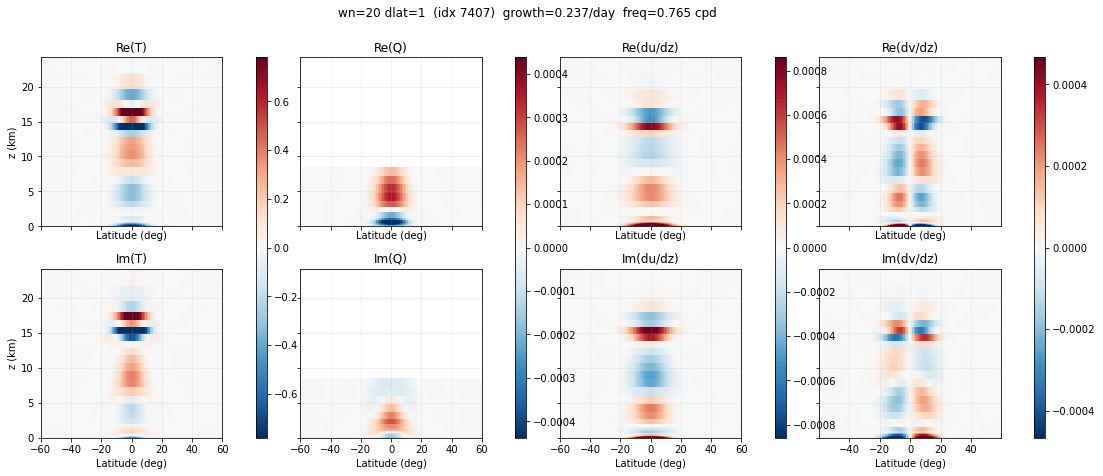

Mode index 7567, growth=0.128/day, freq=-0.818 cpd, |mu|=1.001336


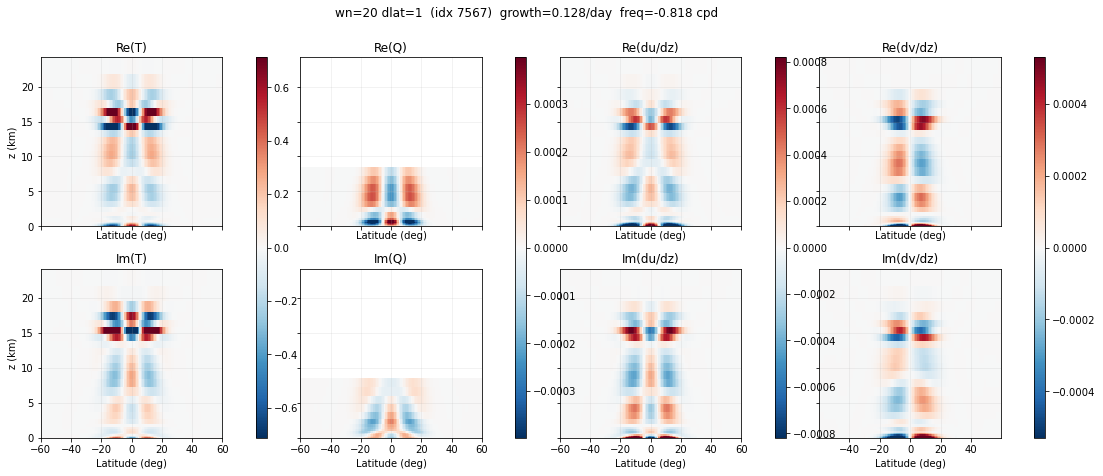

Mode index 7408, growth=0.084/day, freq=0.830 cpd, |mu|=1.000880


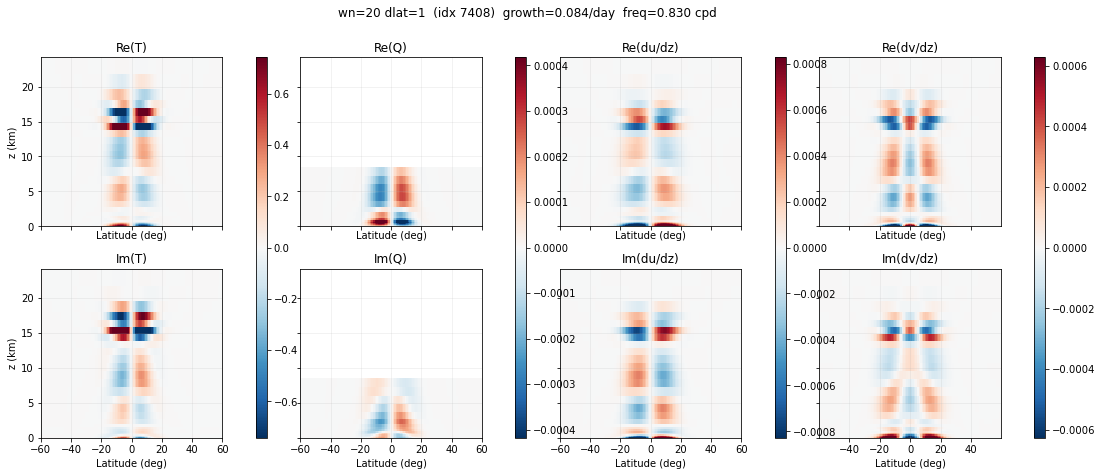

In [15]:
# -----------------------
# Extract mode, reshape, compute T/Q = C*x
# -----------------------
for j in idx_sorted[:min(30, len(idx_sorted))]:  # top 30 modes
    print(f"Mode index {j}, growth={growth[j]:.3f}/day, freq={freq[j]:.3f} cpd, |mu|={abs(mu[j]):.6f}")
    vec = phase_align(V[:, j])
    x, du, dv = reshape_mode(vec, ny)

    # C*x: x is (ny,120), C is (40,120) -> Y is (ny,40)
    Y = x @ C.T
    T = Y[:, :26]        # (ny,26)
    Q = Y[:, 26:40]      # (ny,14)

    # z is bottom->top center levels; you only model bottom 26 layers
    z26 = z[:26]
    z14 = z26[:14]
    '''
    print("Shapes:",
        "T", T.shape, "Q", Q.shape,
        "du", du.shape, "dv", dv.shape,
        "z26", z26.shape, "z14", z14.shape)
    '''

    def symmetric_norm(arrs, pct=99):
        vals = np.concatenate([np.ravel(a) for a in arrs])
        vmax = np.percentile(np.abs(vals), pct)
        if vmax == 0:
            vmax = np.max(np.abs(vals))
        return mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # norms per variable (shared for Re/Im)
    normT  = symmetric_norm([np.real(T),  np.imag(T)],  pct=99)
    normQ  = symmetric_norm([np.real(Q),  np.imag(Q)],  pct=99)
    normdu = symmetric_norm([np.real(du), np.imag(du)], pct=99)
    normdv = symmetric_norm([np.real(dv), np.imag(dv)], pct=99)

    cmap = "RdBu_r"

    # Wider colorbar columns + larger wspace => more gap to the right
    fig = plt.figure(figsize=(18, 7))
    gs = fig.add_gridspec(
        nrows=2, ncols=8,
        width_ratios=[1, 0.06, 1, 0.06, 1, 0.06, 1, 0.06],
        wspace=0.35, hspace=0.25
    )

    # data panels
    axT_re  = fig.add_subplot(gs[0,0])
    axT_im  = fig.add_subplot(gs[1,0], sharex=axT_re, sharey=axT_re)

    axQ_re  = fig.add_subplot(gs[0,2], sharey=axT_re)
    axQ_im  = fig.add_subplot(gs[1,2], sharex=axQ_re, sharey=axT_re)

    axdu_re = fig.add_subplot(gs[0,4], sharey=axT_re)
    axdu_im = fig.add_subplot(gs[1,4], sharex=axdu_re, sharey=axT_re)

    axdv_re = fig.add_subplot(gs[0,6], sharey=axT_re)
    axdv_im = fig.add_subplot(gs[1,6], sharex=axdv_re, sharey=axT_re)

    # colorbar axes (outside)
    caxT  = fig.add_subplot(gs[:,1])
    caxQ  = fig.add_subplot(gs[:,3])
    caxdu = fig.add_subplot(gs[:,5])
    caxdv = fig.add_subplot(gs[:,7])

    # ---- plot panels (only leftmost has y-label) ----
    pcmT_re = plot_lat_z(axT_re, lat_deg, z26, np.real(T),  title="Re(T)", ylabel=True)
    pcmT_im = plot_lat_z(axT_im, lat_deg, z26, np.imag(T),  title="Im(T)", ylabel=True)

    pcmQ_re = plot_lat_z(axQ_re, lat_deg, z14, np.real(Q),  title="Re(Q)", ylabel=False)
    pcmQ_im = plot_lat_z(axQ_im, lat_deg, z14, np.imag(Q),  title="Im(Q)", ylabel=False)

    pcmu_re = plot_lat_z(axdu_re, lat_deg, z26, np.real(du), title="Re(du/dz)", ylabel=False)
    pcmu_im = plot_lat_z(axdu_im, lat_deg, z26, np.imag(du), title="Im(du/dz)", ylabel=False)

    pcmv_re = plot_lat_z(axdv_re, slat_deg, z26, np.real(dv), title="Re(dv/dz)", ylabel=False)
    pcmv_im = plot_lat_z(axdv_im, slat_deg, z26, np.imag(dv), title="Im(dv/dz)", ylabel=False)

    # apply colormap + norm
    for pcm in (pcmT_re, pcmT_im):
        pcm.set_cmap(cmap); pcm.set_norm(normT)
    for pcm in (pcmQ_re, pcmQ_im):
        pcm.set_cmap(cmap); pcm.set_norm(normQ)
    for pcm in (pcmu_re, pcmu_im):
        pcm.set_cmap(cmap); pcm.set_norm(normdu)
    for pcm in (pcmv_re, pcmv_im):
        pcm.set_cmap(cmap); pcm.set_norm(normdv)

    # colorbars: no titles/labels
    fig.colorbar(pcmT_re, cax=caxT)
    fig.colorbar(pcmQ_re, cax=caxQ)
    fig.colorbar(pcmu_re, cax=caxdu)
    fig.colorbar(pcmv_re, cax=caxdv)

    # hide x tick labels on top row
    for ax in (axT_re, axQ_re, axdu_re, axdv_re):
        ax.tick_params(labelbottom=False)

    for ax in (axQ_re, axQ_im, axdu_re, axdu_im, axdv_re, axdv_im):
        ax.tick_params(labelleft=False)

    fig.suptitle(
        f"wn={wn:02d} dlat={dlat}  (idx {j})  growth={growth[j]:.3f}/day  freq={freq[j]:.3f} cpd",
        y=0.98
    )

    plt.show()
